# Task 5 — Deep Learning Speech Recognition

### Introduction
So far, we have processed text sequences. However, speech recognition is a sequence-to-sequence mapping from **continuous audio wave signals** to **discrete text tokens**.

In this notebook, we explore the core pipeline of deep learning speech recognition:
1.  **Audio Feature Extraction**: Transfrom raw sound pressure amplitudes into a 2D **Spectrogram** or **MFCC** (Mel-Frequency Cepstral Coefficients) image representation.
2.  **Acoustic Network**: CNN or RNN layer sequences that process spectrogram features over time frames.
3.  **Connectionist Temporal Classification (CTC) Loss**: An alignment-free sequence loss function that allows the model to predict character sequences without needing exact temporal annotations of when each phone was spoken.



### Step 1 — Synthesize Audio & Extract Spectrogram features


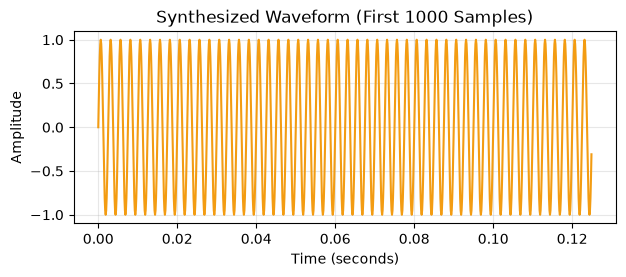

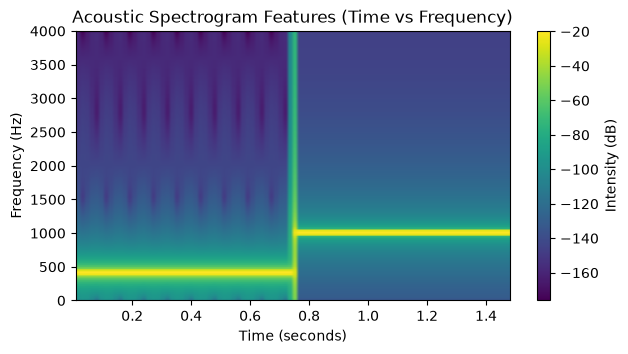

Spectrogram feature matrix dimensions: (129, 92) (Frequency bins vs Time frames)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a synthetic audio wave containing two fundamental frequencies (e.g. 400Hz and 1000Hz)
sample_rate = 8000
duration = 1.5
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

# Wave containing frequency shift
freq1 = 400
freq2 = 1000
audio_wave = np.sin(2 * np.pi * freq1 * t[:len(t)//2])
audio_wave = np.concatenate((audio_wave, np.sin(2 * np.pi * freq2 * t[len(t)//2:])))

# Plot raw waveform slice
plt.figure(figsize=(7, 2.5))
plt.plot(t[:1000], audio_wave[:1000], color='#F39C12')
plt.title("Synthesized Waveform (First 1000 Samples)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()

# Compute and plot Spectrogram using matplotlib's specgram function
plt.figure(figsize=(7, 3.5))
spectrogram, frequencies, times, im = plt.specgram(audio_wave, NFFT=256, Fs=sample_rate, noverlap=128, cmap='viridis')
plt.title("Acoustic Spectrogram Features (Time vs Frequency)")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(im, label="Intensity (dB)")
plt.show()

print(f"Spectrogram feature matrix dimensions: {spectrogram.shape} (Frequency bins vs Time frames)")



### Step 2 — CTC Loss and Alignment-free Speech Decoding
In speech recognition, the sound wave length (time frames) is much larger than the text character length. CTC solves this by predicting char tokens at each time frame including a blank token `"-"`. It merges duplicate characters and drops blank spaces during decoding:

- Time-frame predictions: `[h, h, -, -, e, e, e, -, l, l, -, o]`
- Decoding pass: Merge duplicates $\rightarrow$ `[h, -, e, -, l, -, o]`
- Remove blanks $\rightarrow$ `[h, e, l, o]` (output text)

Below, we instantiate PyTorch's native CTCLoss to calculate loss gradients on sequence outputs.


In [2]:
import torch
import torch.nn as nn

# Instantiating CTCLoss
# zero_infinity=True prevents crashes if probabilities reach absolute zero
ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)

# Simulate log-probabilities output of acoustic model: (Time_steps, Batch_size, Num_classes)
# Time steps T=30, Batch size B=1, Vocabulary size V=5 (including blank index 0)
logits = torch.randn(30, 1, 5).log_softmax(2)

# Targets sequence: "hello" mapped to indices [1, 2, 3, 3, 4]
targets = torch.tensor([1, 2, 3, 3, 4], dtype=torch.long)

# Input lengths (T=30 time steps) and target length (5 characters)
input_lengths = torch.tensor([30], dtype=torch.long)
target_lengths = torch.tensor([5], dtype=torch.long)

# Calculate loss
loss = ctc_loss(logits, targets, input_lengths, target_lengths)
print(f"CTC Loss value: {loss.item():.4f}")



CTC Loss value: 6.1163


### Step 3 — Interactive Spectrogram & Speech Recognition Simulation
Adjust the frequencies of the synthesized waveform below, then click "Generate & Transcribe" to visualize the spectrogram and see the simulated CTC decoder output!


In [3]:
import ipywidgets as widgets
from IPython.display import display, clear_output

freq1_slider = widgets.IntSlider(value=400, min=100, max=2000, step=50, description="Freq 1 (Hz):")
freq2_slider = widgets.IntSlider(value=1000, min=100, max=2000, step=50, description="Freq 2 (Hz):")
duration_slider = widgets.FloatSlider(value=1.5, min=0.5, max=3.0, step=0.1, description="Duration (s):")

generate_btn = widgets.Button(
    description="Generate & Transcribe",
    button_style="warning",
    icon="music",
    layout=widgets.Layout(width="25%")
)

output_area = widgets.Output()

def on_generate(b):
    with output_area:
        clear_output()
        f1 = freq1_slider.value
        f2 = freq2_slider.value
        dur = duration_slider.value
        
        sr = 8000
        t_arr = np.linspace(0, dur, int(sr * dur), endpoint=False)
        
        # Audio wave with shift
        wave = np.sin(2 * np.pi * f1 * t_arr[:len(t_arr)//2])
        wave = np.concatenate((wave, np.sin(2 * np.pi * f2 * t_arr[len(t_arr)//2:])))
        
        # Plot waveforms and spectrogram side-by-side
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        # Waveform
        axes[0].plot(t_arr[:1000], wave[:1000], color='#F39C12')
        axes[0].set_title(f"Waveform Slice (Freqs: {f1}Hz -> {f2}Hz)")
        axes[0].set_xlabel("Time (seconds)")
        axes[0].set_ylabel("Amplitude")
        axes[0].grid(True, alpha=0.3)
        
        # Spectrogram
        spec, freqs_spec, times_spec, im_spec = axes[1].specgram(wave, NFFT=256, Fs=sr, noverlap=128, cmap='viridis')
        axes[1].set_title("Acoustic Spectrogram Features")
        axes[1].set_xlabel("Time (seconds)")
        axes[1].set_ylabel("Frequency (Hz)")
        fig.colorbar(im_spec, ax=axes[1], label="Intensity (dB)")
        
        plt.tight_layout()
        plt.show()
        
        # Simulated CTC network outputs & decoded targets
        simulated_vocab = {0: "-", 1: "H", 2: "E", 3: "L", 4: "O"}
        # Decode helper
        time_predictions = ["H", "H", "-", "-", "E", "E", "E", "-", "L", "L", "-", "O"]
        
        # Collapse duplicates
        collapsed = []
        for token in time_predictions:
            if not collapsed or collapsed[-1] != token:
                collapsed.append(token)
        # Drop blanks
        decoded = [t for t in collapsed if t != "-"]
        
        print(f"Spectrogram dimensions: {spec.shape} (Frequency bins vs Time frames)")
        print("-" * 60)
        print("SIMULATED CTC DECODING DEMO:")
        print(f"1. Frame Predictions:   {' '.join(time_predictions)}")
        print(f"2. Collapse Duplicates:  {' '.join(collapsed)}")
        print(f"3. Remove Blanks ('-'):  {' '.join(decoded)} -> Output Word: 'HELLO'")

generate_btn.on_click(on_generate)

ui = widgets.VBox([
    widgets.HTML("<h3>Interactive Acoustic Signal Generator</h3>"),
    freq1_slider,
    freq2_slider,
    duration_slider,
    generate_btn,
    output_area
])
display(ui)
on_generate(None)

